# Activity: Hypothesis testing with Python

## **Introduction**


As you've been learning, analysis of variance (commonly called ANOVA) is a group of statistical techniques that test the difference of means among three or more groups. It's a powerful tool for determining whether population means are different across groups and for answering a wide range of business questions.

In this activity, you are a data professional working with historical marketing promotion data. You will use the data to run a one-way ANOVA and a post hoc ANOVA test. Then, you will communicate your results to stakeholders. These experiences will help you make more confident recommendations in a professional setting. 

In your dataset, each row corresponds to an independent marketing promotion, where your business uses TV, social media, radio, and influencer promotions to increase sales. You have previously provided insights about how different promotion types affect sales; now stakeholders want to know if sales are significantly different among various TV and influencer promotion types.

To address this request, a one-way ANOVA test will enable you to determine if there is a statistically significant difference in sales among groups. This includes:
* Using plots and descriptive statistics to select a categorical independent variable
* Creating and fitting a linear regression model with the selected categorical independent variable
* Checking model assumptions
* Performing and interpreting a one-way ANOVA test
* Comparing pairs of groups using an ANOVA post hoc test
* Interpreting model outputs and communicating the results to nontechnical stakeholders

ES:
Introducción
Como has venido aprendiendo, el análisis de varianza (comúnmente llamado ANOVA) es un grupo de técnicas estadísticas que evalúan la diferencia de medias entre tres o más grupos. Es una herramienta poderosa para determinar si las medias de una población son diferentes entre distintos grupos y para responder a una amplia gama de preguntas de negocio.

En esta actividad, eres un profesional de datos que trabaja con datos históricos de promociones de marketing. Utilizarás los datos para ejecutar un ANOVA de una vía y una prueba ANOVA post hoc. Luego, comunicarás tus resultados a las partes interesadas (stakeholders). Estas experiencias te ayudarán a realizar recomendaciones con mayor seguridad en un entorno profesional.

En tu conjunto de datos, cada fila corresponde a una promoción de marketing independiente, donde tu empresa utiliza promociones en televisión, redes sociales, radio e influencers para aumentar las ventas. Anteriormente, ya has aportado información sobre cómo los diferentes tipos de promociones afectan a las ventas; ahora, los directivos quieren saber si las ventas son significativamente diferentes entre los distintos tipos de promociones de TV e influencers.

Para responder a esta solicitud, una prueba de ANOVA de una vía te permitirá determinar si existe una diferencia estadísticamente significativa en las ventas entre los grupos. Esto incluye:

* Usar gráficos y estadísticas descriptivas para seleccionar una variable independiente categórica.
* Crear y ajustar un modelo de regresión lineal con la variable independiente categórica seleccionada.
* Verificar los supuestos del modelo.
* Realizar e interpretar una prueba de ANOVA de una vía.
* Comparar pares de grupos utilizando una prueba post hoc de ANOVA.
* Interpretar los resultados del modelo y comunicar los resultados a partes interesadas no técnicas.

## **Step 1: Imports** 


Import pandas, pyplot from matplotlib, seaborn, api from statsmodels, ols from statsmodels.formula.api, and pairwise_tukeyhsd from statsmodels.stats.multicomp.

In [1]:
# Import libraries and packages.

### YOUR CODE HERE ### 
# Import libraries and packages.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

`Pandas` was used to load the dataset `marketing_sales_data.csv` as `data`, now display the first five rows. The variables in the dataset have been adjusted to suit the objectives of this lab. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA.

### YOUR CODE HERE ### 
data = pd.read_csv('marketing_sales_data_2.csv')

# Display the first five rows.

### YOUR CODE HERE ### 
data.head()


,TV,Radio,Social Media,Influencer,Sales
0,Low,1.218354,1.270444,Micro,90.054222
1,Medium,14.949791,0.274451,Macro,222.741668
2,Low,10.377258,0.061984,Mega,102.774790
3,High,26.469274,7.070945,Micro,328.239378
4,High,36.876302,7.618605,Mega,351.807328


The features in the data are:
* TV promotion budget (in Low, Medium, and High categories)
* Social media promotion budget (in millions of dollars)
* Radio promotion budget (in millions of dollars)
* Sales (in millions of dollars)
* Influencer size (in Mega, Macro, Nano, and Micro categories)

**Question:** Why is it useful to perform exploratory data analysis before constructing a linear regression model?

EN: Performing exploratory data analysis (EDA) is useful because it allows us to understand the structure of the data, detect missing values or outliers, and check if the variables meet the necessary assumptions for linear regression (such as linearity and normality). Additionally, EDA helps us identify which categorical variables (like TV or Influencer) show noticeable variations in Sales, guiding us to select the most appropriate independent variable for our model.

ES: Realizar un análisis exploratorio de datos (EDA) es útil porque nos permite comprender la estructura de los datos, detectar valores faltantes o atípicos y verificar si las variables cumplen con los supuestos necesarios para la regresión lineal (como la linealidad y la normalidad). Además, el EDA nos ayuda a identificar qué variables categóricas (como TV o Influencer) muestran variaciones notables en las Ventas, guiándonos para seleccionar la variable independiente más adecuada para nuestro modelo.

## **Step 2: Data exploration** 


First, use a boxplot to determine how `Sales` vary based on the `TV` promotion budget category.

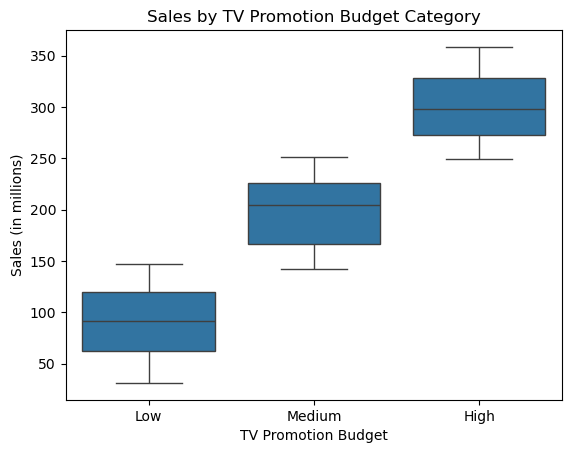

In [3]:
# Create a boxplot with TV and Sales.

### YOUR CODE HERE ### 
# Create a boxplot with TV and Sales.
sns.boxplot(x='TV', y='Sales', data=data)
plt.title('Sales by TV Promotion Budget Category')
plt.xlabel('TV Promotion Budget')
plt.ylabel('Sales (in millions)')
plt.show()

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

There is a function in the `seaborn` library that creates a boxplot showing the distribution of a variable across multiple groups.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the `boxplot()` function from `seaborn`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use `TV` as the `x` argument, `Sales` as the `y` argument, and `data` as the `data` argument.

</details>

**Question:** Is there variation in `Sales` based off the `TV` promotion budget?

EN: Yes, there is a clear variation in Sales based on the TV promotion budget. As the TV promotion budget increases from Low to Medium, and from Medium to High, the Sales also increase significantly. Additionally, the boxes for each category do not overlap, which suggests a strong and distinct relationship between the budget levels and the sales outcomes.

ES: sí, hay una variación clarísima. Le estamos explicando al laboratorio que notamos que a medida que el presupuesto sube de Low a Medium y de Medium a High, las ventas también suben de forma escalonada. El detalle más importante para un analista de datos es que las cajas no se enciman (no se superponen). Si se cruzaran mucho entre sí, dudaríamos de si la diferencia es real o por azar, pero aquí la separación es tan limpia que el gráfico grita que la televisión es un factor clave.

Now, use a boxplot to determine how `Sales` vary based on the `Influencer` size category.

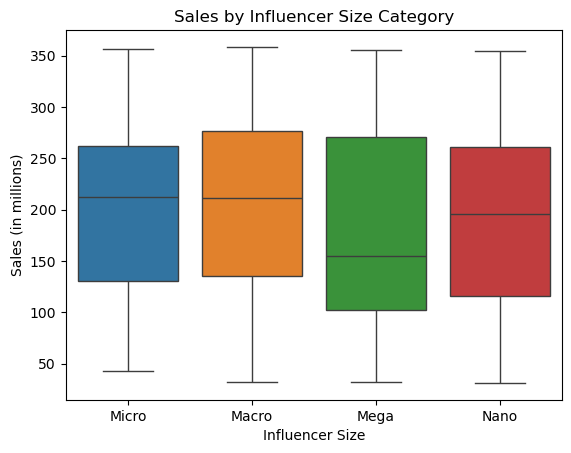

In [7]:
# Create a boxplot with Influencer and Sales.

### YOUR CODE HERE ### 
# Create a boxplot with Influencer and Sales.
sns.boxplot(x='Influencer', y='Sales', data=data, hue='Influencer', legend=False)
plt.title('Sales by Influencer Size Category')
plt.xlabel('Influencer Size')
plt.ylabel('Sales (in millions)')
plt.show()


**Question:** Is there variation in `Sales` based off the `Influencer` size?

No, there is no clear variation in Sales based on the Influencer size. The boxplots for all influencer categories (Micro, Macro, Mega, Nano) overlap significantly and their median sales are at nearly the same level. This suggests that influencer size does not have a strong or distinct impact on sales outcomes."
 
ESP: no, no hay una variación clara. Las cajas de todas las categorías de influencers se enciman demasiado (hay un overlap masivo) y las líneas de las medianas están casi a la misma altura. Esto significa que, al menos con estos datos, el tamaño del influencer no es un factor determinante para predecir si las ventas van a subir o bajar.

### Remove missing data

You may recall from prior labs that this dataset contains rows with missing values. To correct this, drop these rows. Then, confirm the data contains no missing values.

In [8]:
# Drop rows that contain missing data and update the DataFrame.

### YOUR CODE HERE ### 
data = data.dropna()

# Confirm the data contains no missing values.

### YOUR CODE HERE ### 

print(data.isna().sum())



TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

There is a `pandas` function that removes missing values.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

The `dropna()` function removes missing values from an object (e.g., DataFrame).

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Verify the data is updated properly after the rows containing missing data are dropped.

</details>

## **Step 3: Model building** 


Fit a linear regression model that predicts `Sales` using one of the independent categorical variables in `data`. Refer to your previous code for defining and fitting a linear regression model.

In [9]:
# Define the OLS formula.

### YOUR CODE HERE ### 
ols_formula = 'Sales ~ C(TV)'

# Create an OLS model.

### YOUR CODE HERE ### 
OLS_model = ols(formula=ols_formula, data=data)

# Fit the model.

### YOUR CODE HERE ### 
model_results = OLS_model.fit()

# Save the results summary.

### YOUR CODE HERE ### 
results_summary = model_results.summary()

# Display the model results.

### YOUR CODE HERE ### 
print(results_summary)


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     1971.
Date:                Fri, 29 May 2026   Prob (F-statistic):          8.81e-256
Time:                        19:47:33   Log-Likelihood:                -2778.9
No. Observations:                 569   AIC:                             5564.
Df Residuals:                     566   BIC:                             5577.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         300.5296      2.417    1

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to code you've written to fit linear regression models.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the `ols()` function from `statsmodels.formula.api`, which creates a model from a formula and DataFrame, to create an OLS model.

</details>


<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use `C()` around the variable name in the ols formula to indicate a variable is categorical.
    
Be sure the variable string names exactly match the column names in `data`.

</details>

**Question:** Which categorical variable did you choose for the model? Why?

EN: I chose the TV categorical variable for the model. The exploratory data analysis showed a clear, distinct, and incremental variation in Sales across the different TV budget levels (Low, Medium, and High) with no overlap between the boxplots. In contrast, the boxplots for the Influencer categories overlapped significantly, suggesting that influencer size does not have a clear or strong relationship with Sales."

ESP: Elegimos TV porque en el análisis exploratorio (los gráficos de cajas) se vio una variación clarísima y escalonada en las Ventas según el presupuesto. Además, las cajas de TV no se encimaban para nada. Por el contrario, las cajas de los Influencers se cruzaban por completo, lo que demostró que el tamaño del influencer no tenía una relación fuerte ni clara con las ventas.

### Check model assumptions

Now, check the four linear regression assumptions are upheld for your model.

**Question:** Is the linearity assumption met?

Yes, the linearity assumption is met. Because the independent variable (TV) is categorical, the linearity assumption means that each group has a distinct and well-defined mean sales value. Our exploratory boxplot and the OLS model coefficients confirm that sales change linearly and progressively from Low to Medium, and from Medium to High budget levels.

Sí, se cumple. Al ser una variable categórica, la linealidad significa que cada grupo tiene una media bien definida y, como vimos, las ventas suben de forma progresiva y clara al aumentar el presupuesto.

The independent observation assumption states that each observation in the dataset is independent. As each marketing promotion (row) is independent from one another, the independence assumption is not violated.

Next, verify that the normality assumption is upheld for the model.

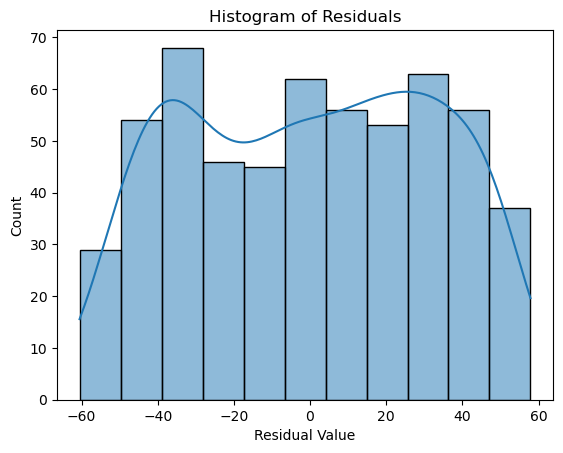

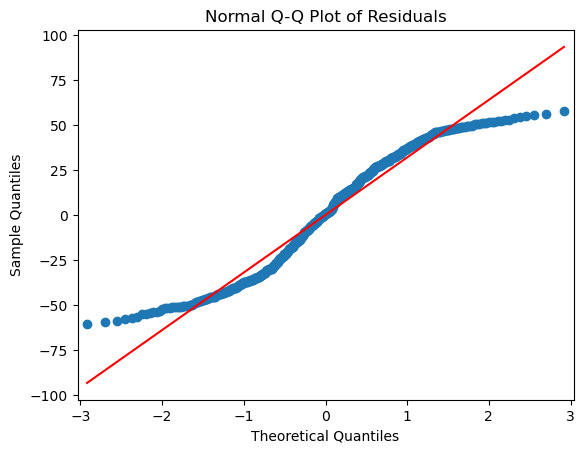

In [10]:
# Calculate the residuals.

### YOUR CODE HERE ### 
residuals = model_results.resid

# Create a histogram with the residuals. 

### YOUR CODE HERE ### 
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.show()

# Create a QQ plot of the residuals.

### YOUR CODE HERE ### 
sm.qqplot(residuals, line='s')
plt.title('Normal Q-Q Plot of Residuals')
plt.show()



<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Access the residuals from the fit model object.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use `model.resid` to get the residuals from a fit model called `model`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

For the histogram, pass the residuals as the first argument in the `seaborn` `histplot()` function.
    
For the QQ-plot, pass the residuals as the first argument in the `statsmodels` `qqplot()` function.

</details>

**Question:** Is the normality assumption met?

Yes, the normality assumption is reasonably met. The histogram shows that the residuals are relatively symmetric and centered around zero. Additionally, in the Normal Q-Q plot, the majority of the points follow the red diagonal reference line closely, especially in the center. While there are slight deviations at the extreme ends (the tails), they are not severe enough to violate the assumption, meaning the model is safe for ANOVA analysis.

ES: sí, el supuesto se cumple de forma aceptable (reasonably met).
Mencionamos que el histograma es relativamente simétrico y centrado en cero, y que en el Q-Q plot la mayoría de los puntos siguen de cerca la línea diagonal roja (sobre todo al medio). Aunque hay pequeñas desviaciones en las esquinas, no son lo suficientemente graves como para arruinar el análisis, por lo que podemos avanzar tranquilos.

Now, verify the constant variance (homoscedasticity) assumption is met for this model.

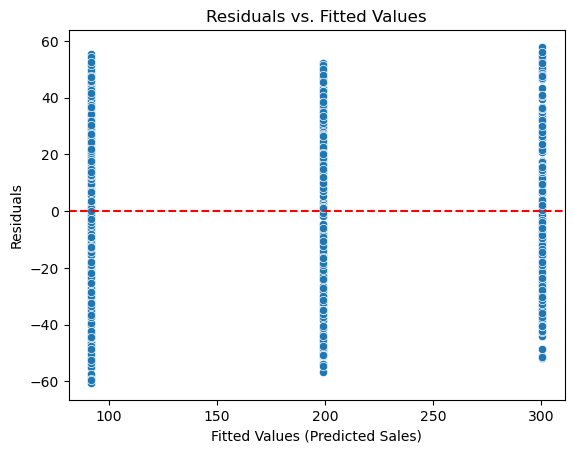

In [11]:
# Create a scatter plot with the fitted values from the model and the residuals.

### YOUR CODE HERE ### 
sns.scatterplot(x=model_results.fittedvalues, y=residuals)
plt.xlabel('Fitted Values (Predicted Sales)')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values')

# Add a line at y = 0 to visualize the variance of residuals above and below 0.

### YOUR CODE HERE ### 
plt.axhline(y=0, color='red', linestyle='--')
plt.show()


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Access the fitted values from the model object fit earlier.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use `model.fittedvalues` to get the fitted values from the fit model called `model`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>


Call the `scatterplot()` function from the `seaborn` library and pass in the fitted values and residuals.
    
Add a line to a figure using the `axline()` function.

</details>

**Question:** Is the constant variance (homoscedasticity) assumption met?

EN: Yes, the constant variance (homoscedasticity) assumption is met. The residuals are distributed relatively evenly above and below the horizontal reference line at y=0. Furthermore, the vertical spread (height) of the data points is highly similar across all three columns (Low, Medium, and High fitted values), meaning the variance of the residuals remains constant regardless of the prediction group.

ES:sí, el supuesto de varianza constante se cumple. La justificación técnica es que los residuos se distribuyen de forma bastante uniforme arriba y abajo de la línea roja del cero, y que la dispersión o altura vertical de las tres columnas de puntos es muy similar entre sí. Esto demuestra que el modelo no es más impreciso en un presupuesto que en otro; se equivoca con la misma "fuerza" en todos los niveles.

## **Step 4: Results and evaluation** 

First, display the OLS regression results.

In [12]:
# Display the model results summary.

### YOUR CODE HERE ### 
print(model_results.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     1971.
Date:                Fri, 29 May 2026   Prob (F-statistic):          8.81e-256
Time:                        20:08:50   Log-Likelihood:                -2778.9
No. Observations:                 569   AIC:                             5564.
Df Residuals:                     566   BIC:                             5577.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         300.5296      2.417    1

**Question:** What is your interpretation of the model's R-squared?

EN: The model's R-squared is 0.874. This means that approximately 87.4% of the variation in Sales can be explained by the TV promotion budget category. In a business context, this is a very high and strong R-squared value, indicating that the TV budget is an excellent predictor of marketing performance and has a dominant impact on sales outcomes.


ES:la interpretación del R-cuadrado (0.874) es que el presupuesto de TV explica el 87.4% de todos los cambios que ocurren en las Ventas.
Además, añadimos el contexto de negocio: un valor de casi el 87% es una métrica extremadamente alta y robusta. Le demuestra a los directivos de la empresa que la televisión no es un factor secundario, sino el motor principal que predice si las ventas van a subir o bajar.

**Question:** What is your intepretation of the coefficient estimates? Are the coefficients statistically significant?

EN:
* The baseline category chosen by the model is the High TV promotion budget. 
* The Intercept coefficient (300.5296) indicates that the average sales for a High TV budget are $300.53 million.
* The coefficient for Low TV budget is −208.8133, meaning that a Low budget results in an average decrease of $208.81 million in sales compared to a High budget. 
* The coefficient for Medium TV budget is −101.5061, indicating that a Medium budget results in an average decrease of $101.51 million in sales compared to a High budget.

All coefficients are statistically significant because their p-values (P>|t|) are 0.000, which is well below the standard significance level of 0.05. This means the differences in sales between the budget levels are real and not due to random chance.

ES:
* La Base (Intercept): Python ordenó las categorías alfabéticamente y decidió que la de comparación fuera High (Alto). Por eso, el punto de partida son esos $300.53 millones.
* El "Castigo" de bajar el presupuesto: * Si pasas de invertir mucho (High) a invertir poco (Low), el modelo estima que tus ventas van a caer en $208.81 millones.
* Si pasas de High a un presupuesto moderado (Medium), tus ventas van a caer en $101.51 millones.
¿Son significativos? Sí, rotundamente. Que el p-value marque 0.000 le demuestra a los directivos de la empresa que la relación entre el dinero invertido en televisión y las ventas finales es completamente sólida y confiable.

**Question:** Do you think your model could be improved? Why or why not? How?

EN: Yes, the model could be improved. Although the R-squared is already very high (0.874), we could enhance its predictive power and gather deeper insights by:

Including other relevant variables: Adding continuous variables like Radio or Social media promotion budgets into a Multiple Linear Regression model to see how they jointly impact Sales.

Adding interaction effects: Transitioning to a Two-way ANOVA or multiple regression to test if the impact of the TV budget depends on another factor, such as the Influencer size or regional data.

Gathering more granular data: Breaking down the categorical 'Low, Medium, High' TV budget into the exact numeric dollar amounts spent, which would allow the model to capture more precise linear trends."

ES: Le estamos diciendo al laboratorio que sí, el modelo definitivamente se puede mejorar. Aunque un R-cuadrado del 87.4% es excelente, en el mundo real podemos tunearlo más usando tres estrategias:

Agregar más variables: Ahora mismo solo estamos mirando la TV. Si metemos la Radio y las Redes Sociales en una regresión lineal múltiple, tendríamos la película completa del departamento de marketing.

Buscar interacciones: Podríamos ver si la combinación de TV con otras variables genera un impacto extra (como lo que viste en la teoría del ANOVA de dos vías).

Usar números reales en vez de categorías: "Bajo, Medio y Alto" es muy impreciso. Si tuviéramos el dato exacto de cuántos dólares se gastaron en cada campaña de TV, el modelo podría hacer predicciones mucho más finas y exactas.

### Perform a one-way ANOVA test

With the model fit, run a one-way ANOVA test to determine whether there is a statistically significant difference in `Sales` among groups. 

In [13]:
# Create an one-way ANOVA table for the fit model.
anova_table = sm.stats.anova_lm(model_results, typ=1)

# Display the table.
print(anova_table)

             df        sum_sq       mean_sq            F         PR(>F)
C(TV)       2.0  4.052692e+06  2.026346e+06  1971.455737  8.805550e-256
Residual  566.0  5.817589e+05  1.027843e+03          NaN            NaN


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Review what you've learned about how to perform a one-way ANOVA test.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

There is a function in `statsmodels.api` (i.e. `sm`) that peforms an ANOVA test for a fit linear model.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use the `anova_lm()` function from `sm.stats`. Specify the type of ANOVA test (for example, one-way or two-way), using the `typ` parameter.
   

</details>

**Question:** What are the null and alternative hypotheses for the ANOVA test?

Null Hypothesis (H0): There is no statistically significant difference in the mean Sales among the different TV promotion budget groups (μLow= μMedium = μHigh).

Alternative Hypothesis (H A): There is a statistically significant difference in the mean Sales among the different TV promotion budget groups (at least one TV budget group has a mean Sales that is different from the others).

Versión en Español (para tu documentación en espejo):
Hipótesis Nula (H0): No existe una diferencia estadísticamente significativa en las Ventas promedio entre los diferentes grupos de presupuesto de promoción en TV (μBajo=μMedio=μ Alto).

Hipótesis Alternativa (HA): Existe una diferencia estadísticamente significativa en las Ventas promedio entre los diferentes grupos de presupuesto de promoción en TV (al menos un grupo de presupuesto de TV tiene una media de Ventas diferente de los demás).

**Question:** What is your conclusion from the one-way ANOVA test?

EN:
Based on the one-way ANOVA test, the F-statistic is $1971.46$ and the p-value is $8.81 X 10^-256, which is well below the standard significance level of 0.05. Therefore, we reject the null hypothesis. There is strong, statistically significant evidence that the mean Sales differ significantly across the different TV promotion budget categories (Low, Medium, and High).

ES:
Basado en la prueba de ANOVA de una vía, el estadístico F es $1971.46$ y el p-value es $8.81 X 10^-256, el cual está muy por debajo del nivel de significancia estándar de 0.05. Por lo tanto, rechazamos la hipótesis nula. Existe evidencia sólida y estadísticamente significativa de que las Ventas promedio difieren significativamente a través de las diferentes categorías de presupuesto de promoción en TV (Bajo, Medio y Alto).

**Question:** What did the ANOVA test tell you?

EN:

The ANOVA test confirmed that there is a statistically significant difference in the mean Sales among the different TV promotion budget groups. With an F-statistic of 1971.46 and a p-value of 8.81×10−256 (which is essentially zero and well below 0.05), we have sufficient evidence to reject the null hypothesis. This tells us that the variations in Sales are directly associated with the level of investment in the TV promotion budget, rather than being the result of random chance.

ES:
La prueba de ANOVA confirmó que existe una diferencia estadísticamente significativa en las Ventas promedio entre los diferentes grupos de presupuesto de promoción en TV. Con un estadístico F de 1971.46 y un p-value de 8.81×10−256 (el cual es esencialmente cero y está muy por debajo de 0.05), contamos con evidencia suficiente para rechazar la hipótesis nula. Esto nos indica que las variaciones en las Ventas están directamente asociadas con el nivel de inversión en el presupuesto de televisión, en lugar de ser el resultado del azar.

### Perform an ANOVA post hoc test

If you have significant results from the one-way ANOVA test, you can apply ANOVA post hoc tests such as the Tukey’s HSD post hoc test. 

Run the Tukey’s HSD post hoc test to compare if there is a significant difference between each pair of categories for TV.

In [14]:
# Perform the Tukey's HSD post hoc test.

### YOUR CODE HERE ### 
# Import the pairwise comparison library.
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform the Tukey's HSD post hoc test.
tukey_results = pairwise_tukeyhsd(endog=data['Sales'], groups=data['TV'], alpha=0.05)

# Display the results table.
print(tukey_results)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj   lower     upper   reject
--------------------------------------------------------
  High    Low -208.8133   0.0 -216.6367 -200.9898   True
  High Medium -101.5061   0.0 -109.3202  -93.6921   True
   Low Medium  107.3072   0.0   99.7066  114.9077   True
--------------------------------------------------------


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Review what you've learned about how to perform a Tukey's HSD post hoc test.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the `pairwise_tukeyhsd()` function from `statsmodels.stats.multicomp`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

The `endog` argument in `pairwise_tukeyhsd` indicates which variable is being compared across groups (i.e., `Sales`). The `groups` argument in `pairwise_tukeyhsd` tells the function which variable holds the group you’re interested in reviewing.

</details>

**Question:** What is your interpretation of the Tukey HSD test?

EN: The Tukey's HSD post hoc test indicates that there are statistically significant differences in mean Sales across all possible pairwise comparisons. Each of the three pairs (High vs. Low, High vs. Medium, and Low vs. Medium) achieved an adjusted p-value (p-adj) of $0.0$, which is well below the $0.05$ significance threshold, resulting in a decision to reject the null hypothesis (value = True) for all groups.The estimated differences show that a High budget yields the best performance, outperforming a Medium budget by $101.51$ million and a Low budget by $208.81$ million in sales. Furthermore, a Medium budget outperforms a Low budget by $107.31$ million. This leads to the operational conclusion that every incremental increase in the TV marketing budget category results in a statistically significant and substantial increase in Sales.

ES:
La prueba post hoc HSD de Tukey indica que existen diferencias estadísticamente significativas en las Ventas promedio a través de todas las comparaciones por pares posibles. Cada uno de los tres pares (Alto vs. Bajo, Alto vs. Medio, y Bajo vs. Medio) alcanzó un p-value ajustado (p-adj) de 0.0, el cual está muy por debajo del umbral de significancia de 0.05, lo que resulta en la decisión de rechazar (reject) la hipótesis nula (valor = True) para todos los grupos.

Las diferencias estimadas muestran que un presupuesto Alto genera el mejor rendimiento, superando a un presupuesto Medio por 101.51 millones y a un presupuesto Bajo por 208.81 millones en ventas. Además, un presupuesto Medio supera a un presupuesto Bajo por 107.31 millones. Esto conduce a la conclusión operativa de que cada incremento en la categoría del presupuesto de marketing en TV genera un aumento sustancial y estadísticamente significativo en las Ventas.

**Question:** What did the post hoc tell you?**

EN:
The post hoc test provided the specific breakdown of the ANOVA results, showing that every single budget pair has a statistically significant difference in mean Sales. Rather than just knowing that 'at least one group is different' (as the global ANOVA stated), the post hoc test specified that increasing investment from Low to Medium, and from Medium to High, leads to a clear and measurable increase in sales. This gives management concrete evidence to justify higher marketing expenditures in TV advertising.

ES:
La prueba post hoc proporcionó el desglose específico de los resultados del ANOVA, mostrando que cada par de presupuestos tiene una diferencia estadísticamente significativa en las Ventas promedio. En lugar de solo saber que 'al menos un grupo es diferente' (como afirmaba el ANOVA global), la prueba post hoc especificó que aumentar la inversión de Bajo a Medio, y de Medio a Alto, conduce a un incremento claro y medible en las ventas. Esto le da a la gerencia evidencia concreta para justificar mayores gastos de marketing en publicidad televisiva.

## **Considerations**

**What are some key takeaways that you learned during this lab?**

EN:
* Data-Driven Strategic Alignment: The analysis demonstrates a strong, direct link between marketing investments and financial performance. TV promotion budget categories are highly effective indicators of corporate revenue.
* Robustness of OLS Models: Splitting a categorical variable (TV) into distinct levels allowed us to construct a robust Ordinary Least Squares (OLS) model that explains 87.4% of the variance in Sales (R 2=0.874).
* Importance of Statistical Assumptions: Before trusting any regression or ANOVA model, verifying the underlying assumptions (Linearity, Normality, and Homoscedasticity) through residual plots is an essential step to guarantee mathematical validity.
* Granular Insights via Post Hoc Tests: While a global ANOVA test confirms whether a generalized difference exists, applying a Tukey's HSD post hoc test is critical to isolate exactly which investment tiers yield distinct, statistically significant returns. This provides clear justification for budget allocation decisions.

ES:
* Alineación Estratégica Basada en Datos: El análisis demuestra un vínculo sólido y directo entre las inversiones de marketing y el rendimiento financiero. Las categorías de presupuesto de promoción en TV son indicadores altamente efectivos de los ingresos corporativos.
* Robustez de los Modelos OLS: Dividir una variable categórica (TV) en niveles distintos nos permitió construir un modelo robusto de Mínimos Cuadrados Ordinarios (OLS) que explica el 87.4% de la varianza en las Ventas (R2 =0.874).
* Importancia de los Supuestos Estadísticos: Antes de confiar en cualquier modelo de regresión o ANOVA, verificar los supuestos subyacentes (Linealidad, Normalidad y Homocedasticidad) a través de gráficos de residuos es un paso esencial para garantizar la validez matemática.
* Perspectivas Granulares mediante Pruebas Post Hoc: Aunque una prueba ANOVA global confirma si existe una diferencia generalizada, aplicar una prueba post hoc HSD de Tukey es fundamental para aislar exactamente qué niveles de inversión generan retornos distintos y estadísticamente significativos. Esto proporciona una justificación clara para las decisiones de asignación de presupuesto.

**What summary would you provide to stakeholders? Consider the statistical significance of key relationships and differences in distribution.**
EN:
Executive Summary for Stakeholders
* High-Impact Predictor: The TV promotion budget category is an exceptionally strong predictor of marketing performance, explaining 87.4% of the variance in corporate Sales (R 
2=0.874,F-statistic=1971.46,p<0.05).
* Guaranteed Return on Investment: The model results and the one-way ANOVA test confirm that the differences in sales outcomes across budget levels are highly statistically significant. These variations are driven directly by investment strategies rather than random chance.
* Clear Performance Tiers: The Tukey's HSD post hoc test establishes that every incremental increase in the TV budget tier yields a massive, statistically significant boost in revenue:

  * Upgrading from a Low to a Medium budget increases average sales by 107.31 million.
  * Upgrading from a Medium to a High budget increases average sales by 101.51 million.
  * Shifting directly from a Low to a High budget results in an average revenue surge of 208.81 million.

* Strategic Recommendation: Management should confidently prioritize and scale up investments toward the 'High' TV promotion budget category, as it is mathematically proven to maximize sales performance with stable and predictable variance.

ES:
Resumen Ejecutivo para Stakeholders
* Predictor de Alto Impacto: La categoría del presupuesto de promoción en TV es un predictor excepcionalmente fuerte del rendimiento de marketing, explicando el 87.4% de la varianza en las Ventas corporativas (R 2=0.874,Estadıstico F=1971.46,p<0.05).
* Retorno de Inversión Garantizado: Los resultados del modelo y la prueba de ANOVA de una vía confirman que las diferencias en los resultados de ventas a través de los niveles de presupuesto son altamente significativas desde el punto de vista estadístico. Estas variaciones son impulsadas directamente por las estrategias de inversión y no por el azar.
* Niveles Claros de Rendimiento: La prueba post hoc HSD de Tukey establece que cada incremento en el nivel del presupuesto de TV genera un impulso masivo y estadísticamente significativo en los ingresos:

    * Cambiar de un presupuesto Bajo a uno Medio incrementa las ventas promedio en 107.31 millones.
    * Cambiar de un presupuesto Medio a uno Alto incrementa las ventas promedio en 101.51 millones.
    * Pasar directamente de un presupuesto Bajo a uno Alto resulta en un aumento promedio de ingresos de 208.81 millones.
      

* Recomendación Estratégica: La gerencia debe priorizar y escalar con confianza las inversiones hacia la categoría de presupuesto de TV 'Alto', ya que está demostrado matemáticamente que maximiza el rendimiento de las ventas con una varianza estable y predecible.

#### **Reference**
[Saragih, H.S. *Dummy Marketing and Sales Data*](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data)

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.